<a href="https://colab.research.google.com/github/ViniciusBernardo06/Api-Reserva-de-Eventos/blob/master/Projeto_pratico_scraping_e_machinelaerning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd


In [ ]:
def extrair_dados():
  url = 'https://books.toscrape.com/catalogue/page-1.html'
  response = requests.get(url)
  soup = BeautifulSoup(response.content, 'html.parser')

  livrots = []
  for item in soup.find_all('article', class_='product_pod'):
    titulo = item.h3.a['title']
    preco = item.find('p', class_='price_color').text
    avaliacao = item.p['class'][1]
    livrots.append([titulo, preco, avaliacao])
  return pd.DataFrame(livrots, columns=['Titulo', 'Preco', 'Avaliacao'])

Criando DataFrame


In [ ]:
df_livros = extrair_dados()
print(df_livros)

                                               Titulo   Preco Avaliacao
0                                A Light in the Attic  £51.77     Three
1                                  Tipping the Velvet  £53.74       One
2                                          Soumission  £50.10       One
3                                       Sharp Objects  £47.82      Four
4               Sapiens: A Brief History of Humankind  £54.23      Five
5                                     The Requiem Red  £22.65       One
6   The Dirty Little Secrets of Getting Your Dream...  £33.34      Four
7   The Coming Woman: A Novel Based on the Life of...  £17.93     Three
8   The Boys in the Boat: Nine Americans and Their...  £22.60      Four
9                                     The Black Maria  £52.15       One
10     Starving Hearts (Triangular Trade Trilogy, #1)  £13.99       Two
11                              Shakespeare's Sonnets  £20.66      Four
12                                        Set Me Free  £17.46   

In [ ]:
def extrair_dados(numero_pagina):
  url = f'https://books.toscrape.com/catalogue/page-{numero_pagina}.html'
  response = requests.get(url)
  soup = BeautifulSoup(response.content, 'html.parser')

  livrots = []
  for item in soup.find_all('article', class_='product_pod'):
    titulo = item.h3.a['title']
    preco = item.find('p', class_='price_color').text
    avaliacao = item.p['class'][1]
    livrots.append([titulo, preco, avaliacao])
  return pd.DataFrame(livrots, columns=['Titulo', 'Preco', 'Avaliacao'])


In [ ]:
df_livros1 = extrair_dados(1)
print(df_livros1)

                                               Titulo   Preco Avaliacao
0                                A Light in the Attic  £51.77     Three
1                                  Tipping the Velvet  £53.74       One
2                                          Soumission  £50.10       One
3                                       Sharp Objects  £47.82      Four
4               Sapiens: A Brief History of Humankind  £54.23      Five
5                                     The Requiem Red  £22.65       One
6   The Dirty Little Secrets of Getting Your Dream...  £33.34      Four
7   The Coming Woman: A Novel Based on the Life of...  £17.93     Three
8   The Boys in the Boat: Nine Americans and Their...  £22.60      Four
9                                     The Black Maria  £52.15       One
10     Starving Hearts (Triangular Trade Trilogy, #1)  £13.99       Two
11                              Shakespeare's Sonnets  £20.66      Four
12                                        Set Me Free  £17.46   

In [ ]:
df_livros2 = extrair_dados(2)
print(df_livros2)

                                               Titulo   Preco Avaliacao
0                                         In Her Wake  £12.84       One
1                                     How Music Works  £37.32       Two
2   Foolproof Preserving: A Guide to Small Batch J...  £30.52     Three
3                          Chase Me (Paris Nights #2)  £25.27      Five
4                                          Black Dust  £34.53      Five
5                       Birdsong: A Story in Pictures  £54.64     Three
6   America's Cradle of Quarterbacks: Western Penn...  £22.50     Three
7                      Aladdin and His Wonderful Lamp  £53.13     Three
8   Worlds Elsewhere: Journeys Around Shakespeare’...  £40.30      Five
9                                      Wall and Piece  £44.18      Four
10  The Four Agreements: A Practical Guide to Pers...  £17.66      Five
11  The Five Love Languages: How to Express Heartf...  £31.05     Three
12                                  The Elephant Tree  £23.82   

**Formatação do DataFrame**

set_table_styles: permite a inserção de regras CSS em qualquer elemento do DOM
obs: O atributo style pertence a classe Styler do Pandas

In [ ]:
df_livros_formatado = df_livros.style.set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])

In [ ]:
df_livros_formatado

,Titulo,Preco,Avaliacao
0,A Light in the Attic,£51.77,Three
1,Tipping the Velvet,£53.74,One
2,Soumission,£50.10,One
3,Sharp Objects,£47.82,Four
4,Sapiens: A Brief History of Humankind,£54.23,Five
5,The Requiem Red,£22.65,One
6,The Dirty Little Secrets of Getting Your Dream Job,£33.34,Four
7,"The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull",£17.93,Three
8,The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics,£22.60,Four
9,The Black Maria,£52.15,One


**Formatação do DataFrame**

set_properties(Pandas)

O set_properties é um método usado para injetar delcarações de propriedades CSS

Obs: não devemos usar a propriedade style, pois já foi aplicado ao objeto

In [ ]:
df_livros_formatado = df_livros_formatado.set_properties(**{'text-align': 'left'})

In [ ]:
df_livros_formatado

,Titulo,Preco,Avaliacao
0,A Light in the Attic,£51.77,Three
1,Tipping the Velvet,£53.74,One
2,Soumission,£50.10,One
3,Sharp Objects,£47.82,Four
4,Sapiens: A Brief History of Humankind,£54.23,Five
5,The Requiem Red,£22.65,One
6,The Dirty Little Secrets of Getting Your Dream Job,£33.34,Four
7,"The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull",£17.93,Three
8,The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics,£22.60,Four
9,The Black Maria,£52.15,One


In [ ]:
display(df_livros_formatado)

,Titulo,Preco,Avaliacao
0,A Light in the Attic,£51.77,Three
1,Tipping the Velvet,£53.74,One
2,Soumission,£50.10,One
3,Sharp Objects,£47.82,Four
4,Sapiens: A Brief History of Humankind,£54.23,Five
5,The Requiem Red,£22.65,One
6,The Dirty Little Secrets of Getting Your Dream Job,£33.34,Four
7,"The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull",£17.93,Three
8,The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics,£22.60,Four
9,The Black Maria,£52.15,One


In [ ]:
print(df_livros_formatado)

Erros de visualização por conta da mudança de estrutura.

In [ ]:
df_livros_formatado.dtypes

AttributeError: 'Styler' object has no attribute 'dtypes'

**Atributo .data**

In [ ]:
print(df_livros_formatado.data)

                                               Titulo   Preco Avaliacao
0                                A Light in the Attic  £51.77     Three
1                                  Tipping the Velvet  £53.74       One
2                                          Soumission  £50.10       One
3                                       Sharp Objects  £47.82      Four
4               Sapiens: A Brief History of Humankind  £54.23      Five
5                                     The Requiem Red  £22.65       One
6   The Dirty Little Secrets of Getting Your Dream...  £33.34      Four
7   The Coming Woman: A Novel Based on the Life of...  £17.93     Three
8   The Boys in the Boat: Nine Americans and Their...  £22.60      Four
9                                     The Black Maria  £52.15       One
10     Starving Hearts (Triangular Trade Trilogy, #1)  £13.99       Two
11                              Shakespeare's Sonnets  £20.66      Four
12                                        Set Me Free  £17.46   

In [ ]:
df_livros_formatado.data.dtypes

,0
Titulo,object
Preco,object
Avaliacao,object


**Conversão ao Original**

In [ ]:
df_livros = df_livros_formatado.data

In [ ]:
print(df_livros)

                                               Titulo   Preco Avaliacao
0                                A Light in the Attic  £51.77     Three
1                                  Tipping the Velvet  £53.74       One
2                                          Soumission  £50.10       One
3                                       Sharp Objects  £47.82      Four
4               Sapiens: A Brief History of Humankind  £54.23      Five
5                                     The Requiem Red  £22.65       One
6   The Dirty Little Secrets of Getting Your Dream...  £33.34      Four
7   The Coming Woman: A Novel Based on the Life of...  £17.93     Three
8   The Boys in the Boat: Nine Americans and Their...  £22.60      Four
9                                     The Black Maria  £52.15       One
10     Starving Hearts (Triangular Trade Trilogy, #1)  £13.99       Two
11                              Shakespeare's Sonnets  £20.66      Four
12                                        Set Me Free  £17.46   

Ajuste na Estrutura

In [ ]:
df_livros.dtypes

,0
Titulo,object
Preco,object
Avaliacao,object


Conversão do tipo

In [ ]:
df_livros['Preco'] = df_livros['Preco'].str.replace('£', '').astype(float)

In [ ]:
df_livros


,Titulo,Preco,Avaliacao
0,A Light in the Attic,51.77,Three
1,Tipping the Velvet,53.74,One
2,Soumission,50.10,One
3,Sharp Objects,47.82,Four
4,Sapiens: A Brief History of Humankind,54.23,Five
5,The Requiem Red,22.65,One
6,The Dirty Little Secrets of Getting Your Dream...,33.34,Four
7,The Coming Woman: A Novel Based on the Life of...,17.93,Three
8,The Boys in the Boat: Nine Americans and Their...,22.60,Four
9,The Black Maria,52.15,One


In [ ]:
df_livros.dtypes

,0
Titulo,object
Preco,float64
Avaliacao,object


**Comanda .map**

O comando serve para agilizar a conversão

In [ ]:
mapa_notas = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
df_livros1['Nota'] = df_livros['Avaliacao'].map(mapa_notas)

In [ ]:
print(df_livros1)

                                               Titulo   Preco Avaliacao  Nota
0                                A Light in the Attic  £51.77     Three     3
1                                  Tipping the Velvet  £53.74       One     1
2                                          Soumission  £50.10       One     1
3                                       Sharp Objects  £47.82      Four     4
4               Sapiens: A Brief History of Humankind  £54.23      Five     5
5                                     The Requiem Red  £22.65       One     1
6   The Dirty Little Secrets of Getting Your Dream...  £33.34      Four     4
7   The Coming Woman: A Novel Based on the Life of...  £17.93     Three     3
8   The Boys in the Boat: Nine Americans and Their...  £22.60      Four     4
9                                     The Black Maria  £52.15       One     1
10     Starving Hearts (Triangular Trade Trilogy, #1)  £13.99       Two     2
11                              Shakespeare's Sonnets  £20.66   

**dropna()**

o dropna() é o metodo pandas para eliminar linhas ou colunas com valores nulos

In [ ]:
df_livros_ml = df_livros1[['Preco', 'Nota']].dropna()
df_livros_ml['Preco'] = df_livros_ml['Preco'].str.replace('£', '').astype(float)

In [ ]:
df_livros_ml

,Preco,Nota
0,51.77,3
1,53.74,1
2,50.10,1
3,47.82,4
4,54.23,5
5,22.65,1
6,33.34,4
7,17.93,3
8,22.60,4
9,52.15,1


**.reset_index(drop=True)**

O comando .reste_index(drop=True) reconstrói a numeração das linhas do DataFrame começando do zero(0,1,2,3...)

Obs: Caso o comando dropna() tenha deixado lacunas no indice devido da deleção de

In [ ]:
df_livros_ml_reindexado = df_livros_ml.reset_index(drop=True)
display(df_livros_ml_reindexado)

,Preco,Nota
0,51.77,3
1,53.74,1
2,50.10,1
3,47.82,4
4,54.23,5
5,22.65,1
6,33.34,4
7,17.93,3
8,22.60,4
9,52.15,1


Definindo Índice

In [ ]:
df_livros_ml_reindexado.index = df_livros_ml_reindexado.index + 1
display(df_livros_ml_reindexado)

,Preco,Nota
1,51.77,3
2,53.74,1
3,50.10,1
4,47.82,4
5,54.23,5
6,22.65,1
7,33.34,4
8,17.93,3
9,22.60,4
10,52.15,1


Treinamento e avaliação do modelo

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

Definições de variáveis

In [ ]:
x = df_livros_ml_reindexado[['Nota']]
y = df_livros_ml_reindexado['Preco']

In [ ]:
print(x)

    Nota
1      3
2      1
3      1
4      4
5      5
6      1
7      4
8      3
9      4
10     1
11     2
12     4
13     5
14     5
15     5
16     3
17     1
18     1
19     2
20     2


In [ ]:
X_demonstracao = df_livros_ml_reindexado[['Nota', 'Nota']]
print(X_demonstracao.head())

In [ ]:
print(y)

1     51.77
2     53.74
3     50.10
4     47.82
5     54.23
6     22.65
7     33.34
8     17.93
9     22.60
10    52.15
11    13.99
12    20.66
13    17.46
14    52.29
15    35.02
16    57.25
17    23.88
18    37.59
19    51.33
20    45.17
Name: Preco, dtype: float64


3. Treino e Teste

In [ ]:
X_treino, X_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
print(X_treino)

    Nota
9      4
6      1
12     4
4      4
19     2
17     1
14     5
3      1
10     1
20     2
5      5
13     5
8      3
11     2
15     5
7      4


In [ ]:
print(X_teste)

    Nota
1      3
18     1
16     3
2      1


In [ ]:
print(y_treino)

9     22.60
6     22.65
12    20.66
4     47.82
19    51.33
17    23.88
14    52.29
3     50.10
10    52.15
20    45.17
5     54.23
13    17.46
8     17.93
11    13.99
15    35.02
7     33.34
Name: Preco, dtype: float64


In [ ]:
print(y_teste)

1     51.77
18    37.59
16    57.25
2     53.74
Name: Preco, dtype: float64


In [ ]:
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

LinearRegression()

In [ ]:
previsoes = modelo.predict(X_teste)
erro = mean_squared_error(y_teste, previsoes)
print(f"Modelo Treinado! Erro médio: {erro:.2f}")

Modelo Treinado! Erro médio: 281.98


In [ ]:
print(f"Inclinação (a): {modelo.coef_[0]:.2f}")
print(f"Ponto de partida (b): {modelo.intercept_}")

Inclinação (a): -0.02
Ponto de partida (b): 35.09134831460674


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

erro_real = np.sqrt(erro)

print(f"O RMSE do modelo é: R$ {erro_real:.2f}")

O RMSE do modelo é: R$ 16.79


In [ ]:
import pandas as pd

# 1. Juntamos as notas, os preços reais e as previsões em uma tabela
resultados = pd.DataFrame({
    'Nota do Livro': X_teste['Nota'],
    'Preço Real (£)': y_teste,
    'Preço Previsto da IA (£)': previsoes
})

# 2. Arredondamos as previsões para 2 casas decimais (ficar igual a dinheiro)
resultados['Preço Previsto da IA (£)'] = resultados['Preço Previsto da IA (£)'].round(2)

# 3. Calculamos o erro individual de cada livro (Real menos Previsto)
resultados['Erro (Diferença)'] = (resultados['Preço Real (£)'] - resultados['Preço Previsto da IA (£)']).round(2)

# 4. Mostramos a tabela final
print("\n--- Resultados do Teste ---")
print(resultados)


--- Resultados do Teste ---
    Nota do Livro  Preço Real (£)  Preço Previsto da IA (£)  Erro (Diferença)
1               3           51.77                     35.04             16.73
18              1           37.59                     35.07              2.52
16              3           57.25                     35.04             22.21
2               1           53.74                     35.07             18.67


In [ ]:
import pandas as pd

# 1. Juntamos as notas, os preços reais e as previsões em uma tabela
resultados = pd.DataFrame({
    'Nota do Livro': X_teste['Nota'],
    'Preço Real (£)': y_teste,
    'Preço Previsto da IA (£)': previsoes
})

# 2. Arredondamos as previsões para 2 casas decimais (ficar igual a dinheiro)
resultados['Preço Previsto da IA (£)'] = resultados['Preço Previsto da IA (£)'].round(2)

# 3. Calculamos o erro individual de cada livro (Real menos Previsto)
resultados['Erro (Diferença)'] = (resultados['Preço Real (£)'] - resultados['Preço Previsto da IA (£)']).round(2)

# 4. Mostramos a tabela final
print("\n--- Resultados do Teste ---")
print(resultados)


--- Resultados do Teste ---
    Nota do Livro  Preço Real (£)  Preço Previsto da IA (£)  Erro (Diferença)
1               3           51.77                     35.04             16.73
18              1           37.59                     35.07              2.52
16              3           57.25                     35.04             22.21
2               1           53.74                     35.07             18.67


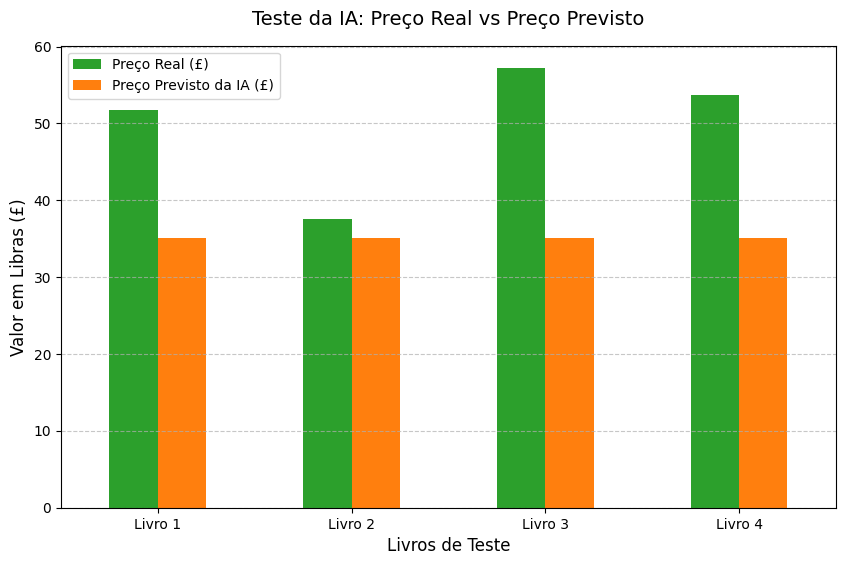

In [ ]:
import matplotlib.pyplot as plt

# 1. Preparamos os dados para o gráfico
# Selecionamos apenas as duas colunas que queremos comparar
df_grafico = resultados[['Preço Real (£)', 'Preço Previsto da IA (£)']]

# 2. Geramos o gráfico de barras agrupadas direto pelo Pandas
# figsize=(10, 6) define o tamanho da janela do gráfico
# color=['verde', 'laranja'] para diferenciar bem as barras
df_grafico.plot(kind='bar', figsize=(10, 6), color=['#2ca02c', '#ff7f0e'])

# 3. Deixamos o gráfico com visual profissional (Títulos e Eixos)
plt.title('Teste da IA: Preço Real vs Preço Previsto', fontsize=14, pad=15)
plt.ylabel('Valor em Libras (£)', fontsize=12)
plt.xlabel('Livros de Teste', fontsize=12)

# 4. Ajustamos os nomes no eixo X (Em vez de 0, 1, 2, 3, colocamos nomes amigáveis)
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=['Livro 1', 'Livro 2', 'Livro 3', 'Livro 4'],
    rotation=0 # Deixa o texto deitado (0 graus) em vez de em pé
)

# 5. Adicionamos uma grade no fundo para facilitar a leitura dos valores
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 6. O grande momento: Mostrar o gráfico na tela!
plt.show()

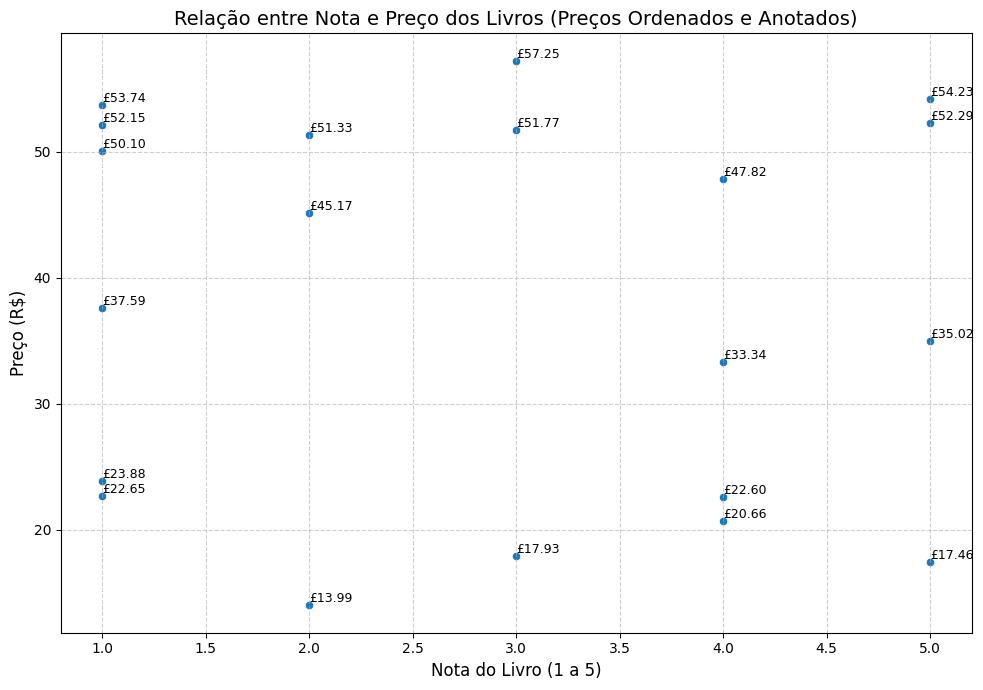

In [ ]:
# 1. Importando as bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Configurando o tamanho do gráfico (opcional, mas fica mais legível)
plt.figure(figsize=(10, 7))

# Sort the DataFrame by 'Preco' in ascending order (as previously requested)
df_sorted = df_livros_ml_reindexado.sort_values(by='Preco', ascending=True)

# 3. Criando o Gráfico de Dispersão (Scatter Plot) com os dados ordenados
sns.scatterplot(data=df_sorted, x='Nota', y='Preco')

# 4. Colocando títulos para não nos perdermos
plt.title('Relação entre Nota e Preço dos Livros (Preços Ordenados e Anotados)', fontsize=14)
plt.xlabel('Nota do Livro (1 a 5)', fontsize=12)
plt.ylabel('Preço (R$)', fontsize=12)

# 5. Adicionando os valores de preço em cada ponto
for i, row in df_sorted.iterrows():
    plt.text(row['Nota'], row['Preco'], f'£{row["Preco"]:.2f}',
             horizontalalignment='left', verticalalignment='bottom', fontsize=9, color='black')

# 6. Exibindo o gráfico na tela
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
df_livros_ordenado_preco = df_livros_ml_reindexado.sort_values(by='Preco', ascending=True)
print(df_livros_ordenado_preco)

    Preco  Nota
11  13.99     2
13  17.46     5
8   17.93     3
12  20.66     4
9   22.60     4
6   22.65     1
17  23.88     1
7   33.34     4
15  35.02     5
18  37.59     1
20  45.17     2
4   47.82     4
3   50.10     1
19  51.33     2
1   51.77     3
10  52.15     1
14  52.29     5
2   53.74     1
5   54.23     5
16  57.25     3
